# Phase 2: Exploratory Data Analysis (EDA)
This notebook analyzes the final cleaned modeling dataset used by the project: `files/dataset/resume-data-with-job-description/final_resume_dataset.parquet`.

This is the most defensible dataset for Phase 2 because it contains the exact resume and job-description pairs that feed the downstream fine-tuning workflow, plus the generated tailored resume objects used later in the pipeline.

What this notebook covers:
- clearly defined group roles and responsibilities
- dataset quality checks
- at least three distinct visualization types
- descriptive statistics (means, medians, correlations)
- extra text-aware features (lexical diversity, token overlap, and outlier flags) to make the results easier to justify

## Team Roles and Responsibilities
These roles are aligned to the actual work represented across `pre_processing.ipynb` and `phase2_eda_colab.ipynb`.

- **Vaishnav Busha**: led the preprocessing workflow in `pre_processing.ipynb`. ensured necessary python packages and sourced custom resumes and custom job descriptions necessary for dataset creation. Assisted in performing google batch API processing for tailored resumes.

- **Swaroop**: Performed dataset cleaning by merging the resume and job description. Performed google batch API processing for tailoring the resumes. focused on exploratory analysis and visual discovery in `phase2_eda_colab.ipynb`, including distribution plots, file-type comparisons, and chart-level interpretation of data spread and skew.

- **Nishith**: Helped in training dataset preparation. handled feature engineering and descriptive statistics for Phase 2, including text-length features, lexical-diversity metrics, overlap features, and the mean/median/correlation summaries. 

- **Talha Khan**: handled dataset-quality validation and reporting support, including reviewing the structured `tailored_resume` outputs, helping justify the EDA findings, and preparing the written interpretation for submission/presentation.


In [66]:
# If you are running this in a fresh Colab environment, uncomment the next line.
# !pip install pyarrow seaborn nltk

import json
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from nltk.tokenize import RegexpTokenizer
from nltk.util import ngrams

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

CANDIDATE_PATHS = [
    Path('files/dataset/resume-data-with-job-description/final_resume_dataset.parquet'),
    Path('/content/Resume-Optimizer-QLoRA-Fine-tuned/files/dataset/resume-data-with-job-description/final_resume_dataset.parquet'),
]

DATA_PATH = next((path for path in CANDIDATE_PATHS if path.exists()), None)
if DATA_PATH is None:
    matches = list(Path('.').rglob('final_resume_dataset.parquet'))
    if matches:
        DATA_PATH = matches[0]
    else:
        raise FileNotFoundError(
            'Could not find final_resume_dataset.parquet. Place the notebook in the repo root or upload the dataset to Colab.'
        )

df = pd.read_parquet(DATA_PATH)
print(f'Using dataset: {DATA_PATH}')
print(f'Dataset shape: {df.shape}')
print('Columns:', list(df.columns))


Using dataset: files/dataset/resume-data-with-job-description/final_resume_dataset.parquet
Dataset shape: (1530, 6)
Columns: ['filename', 'filetype', 'resume_text', 'job_description', 'id', 'tailored_resume']


In [67]:
def normalize_tailored_resume(value):
    if isinstance(value, dict):
        return value
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return None
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, dict) else None
        except Exception:
            return None
    return None


def normalize_sequence(value):
    if value is None:
        return []
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (list, tuple)):
        return list(value)
    return []


def count_content_blocks(value):
    if not isinstance(value, dict):
        return 0

    return sum(
        len(normalize_sequence(value.get(field)))
        for field in [
            'experiences', 'education', 'skills', 'projects',
            'certifications', 'awards', 'extracurricular_achievements', 'languages'
        ]
    )


def count_experience_bullets(value):
    if not isinstance(value, dict):
        return 0

    total = 0
    for experience in normalize_sequence(value.get('experiences')):
        if isinstance(experience, dict):
            total += len(normalize_sequence(experience.get('points')))
    return total


def count_skill_items(value):
    if not isinstance(value, dict):
        return 0

    total = 0
    for skill_group in normalize_sequence(value.get('skills')):
        if isinstance(skill_group, dict):
            total += len(normalize_sequence(skill_group.get('data')))
    return total


STOP_WORDS = {
    'the', 'and', 'or', 'a', 'an', 'to', 'of', 'in', 'for', 'on', 'with', 'is', 'are',
    'be', 'as', 'by', 'at', 'from', 'that', 'this', 'it', 'will', 'your', 'you', 'we',
    'our', 'their', 'they', 'has', 'have', 'had', 'was', 'were', 'but', 'if', 'into',
    'than', 'then', 'also', 'can', 'may', 'must', 'using', 'use'
}
TOKENIZER = RegexpTokenizer(r"[A-Za-z][A-Za-z0-9_+.#-]{1,}")


def tokenize_text(text):
    text = str(text).lower()
    tokens = TOKENIZER.tokenize(text)
    return [token for token in tokens if token not in STOP_WORDS]


def lexical_diversity(tokens):
    if not tokens:
        return 0.0
    return len(set(tokens)) / len(tokens)


def overlap_stats(resume_text, job_text):
    resume_tokens = set(tokenize_text(resume_text))
    job_tokens = set(tokenize_text(job_text))
    if not resume_tokens or not job_tokens:
        return 0, 0.0
    shared = resume_tokens & job_tokens
    ratio = len(shared) / len(job_tokens)
    return len(shared), ratio


def top_terms(series, top_n=15):
    token_counter = Counter()
    for text in series.fillna(''):
        token_counter.update(tokenize_text(text))
    return pd.DataFrame(token_counter.most_common(top_n), columns=['term', 'count'])


def average_token_length(tokens):
    tokens = normalize_sequence(tokens)
    if not tokens:
        return 0.0
    return float(np.mean([len(token) for token in tokens]))


def long_token_ratio(tokens, min_length=8):
    tokens = normalize_sequence(tokens)
    if not tokens:
        return 0.0
    long_tokens = [token for token in tokens if len(token) >= min_length]
    return len(long_tokens) / len(tokens)


def top_ngrams(token_series, n=2, top_n=15):
    ngram_counter = Counter()
    for tokens in token_series:
        tokens = normalize_sequence(tokens)
        if len(tokens) >= n:
            joined_ngrams = [' '.join(gram) for gram in ngrams(tokens, n)]
            ngram_counter.update(joined_ngrams)
    return pd.DataFrame(ngram_counter.most_common(top_n), columns=['ngram', 'count'])


eda_df = df.copy()
eda_df['tailored_resume'] = eda_df['tailored_resume'].apply(normalize_tailored_resume)
eda_df['resume_char_count'] = eda_df['resume_text'].fillna('').str.len()
eda_df['resume_word_count'] = eda_df['resume_text'].fillna('').str.split().str.len()
eda_df['job_char_count'] = eda_df['job_description'].fillna('').str.len()
eda_df['job_word_count'] = eda_df['job_description'].fillna('').str.split().str.len()
eda_df['filename_length'] = eda_df['filename'].fillna('').str.len()
eda_df['has_tailored_resume'] = eda_df['tailored_resume'].apply(lambda x: isinstance(x, dict))
eda_df['tailored_experience_count'] = eda_df['tailored_resume'].apply(
    lambda x: len(normalize_sequence(x.get('experiences'))) if isinstance(x, dict) else 0
)
eda_df['tailored_education_count'] = eda_df['tailored_resume'].apply(
    lambda x: len(normalize_sequence(x.get('education'))) if isinstance(x, dict) else 0
)
eda_df['tailored_skill_group_count'] = eda_df['tailored_resume'].apply(
    lambda x: len(normalize_sequence(x.get('skills'))) if isinstance(x, dict) else 0
)
eda_df['tailored_project_count'] = eda_df['tailored_resume'].apply(
    lambda x: len(normalize_sequence(x.get('projects'))) if isinstance(x, dict) else 0
)
eda_df['tailored_certification_count'] = eda_df['tailored_resume'].apply(
    lambda x: len(normalize_sequence(x.get('certifications'))) if isinstance(x, dict) else 0
)
eda_df['tailored_award_count'] = eda_df['tailored_resume'].apply(
    lambda x: len(normalize_sequence(x.get('awards'))) if isinstance(x, dict) else 0
)
eda_df['tailored_achievement_count'] = eda_df['tailored_resume'].apply(
    lambda x: len(normalize_sequence(x.get('extracurricular_achievements'))) if isinstance(x, dict) else 0
)
eda_df['tailored_language_count'] = eda_df['tailored_resume'].apply(
    lambda x: len(normalize_sequence(x.get('languages'))) if isinstance(x, dict) else 0
)
eda_df['tailored_content_block_count'] = eda_df['tailored_resume'].apply(count_content_blocks)
eda_df['tailored_experience_bullet_count'] = eda_df['tailored_resume'].apply(count_experience_bullets)
eda_df['tailored_skill_item_count'] = eda_df['tailored_resume'].apply(count_skill_items)
eda_df['resume_to_job_word_ratio'] = (
    eda_df['resume_word_count'] / eda_df['job_word_count'].replace(0, np.nan)
).fillna(0)
eda_df['resume_tokens'] = eda_df['resume_text'].apply(tokenize_text)
eda_df['job_tokens'] = eda_df['job_description'].apply(tokenize_text)
eda_df['resume_avg_token_length'] = eda_df['resume_tokens'].apply(average_token_length)
eda_df['job_avg_token_length'] = eda_df['job_tokens'].apply(average_token_length)
eda_df['resume_long_token_ratio'] = eda_df['resume_tokens'].apply(long_token_ratio)
eda_df['job_long_token_ratio'] = eda_df['job_tokens'].apply(long_token_ratio)
eda_df['resume_unique_token_count'] = eda_df['resume_tokens'].apply(lambda tokens: len(set(tokens)))
eda_df['job_unique_token_count'] = eda_df['job_tokens'].apply(lambda tokens: len(set(tokens)))
eda_df['resume_lexical_diversity'] = eda_df['resume_tokens'].apply(lexical_diversity)
eda_df['job_lexical_diversity'] = eda_df['job_tokens'].apply(lexical_diversity)

overlap_pairs = eda_df.apply(
    lambda row: overlap_stats(row['resume_text'], row['job_description']),
    axis=1
)
eda_df['shared_token_count'] = overlap_pairs.apply(lambda pair: pair[0])
eda_df['shared_token_ratio'] = overlap_pairs.apply(lambda pair: pair[1])

resume_q1 = eda_df['resume_word_count'].quantile(0.25)
resume_q3 = eda_df['resume_word_count'].quantile(0.75)
resume_iqr = resume_q3 - resume_q1
resume_upper_fence = resume_q3 + 1.5 * resume_iqr
eda_df['resume_length_outlier'] = eda_df['resume_word_count'] > resume_upper_fence

resume_top_terms = top_terms(eda_df['resume_text'])
job_top_terms = top_terms(eda_df['job_description'])
resume_top_bigrams = top_ngrams(eda_df['resume_tokens'], n=2, top_n=12)
job_top_bigrams = top_ngrams(eda_df['job_tokens'], n=2, top_n=12)

eda_df[[
    'filename', 'filetype', 'resume_word_count', 'job_word_count',
    'resume_to_job_word_ratio', 'shared_token_ratio', 'tailored_content_block_count'
]].head()


,filename,filetype,resume_word_count,job_word_count,resume_to_job_word_ratio,shared_token_ratio,tailored_content_block_count
0,00_Willie_Ellis_Go_Python.docx,.docx,992,321,3.090343,0.127778,10
1,10272022 Resume.docx,.docx,1273,399,3.190476,0.072000,10
3,1611617001435.pdf,.pdf,2429,359,6.766017,0.163265,15
6,1KshitijaPatel_Resume.docx,.docx,595,626,0.950479,0.097222,7
7,2020_HWRes.doc,.doc,1675,300,5.583333,0.128342,11


## Dataset Overview
This section validates the dataset before plotting anything. The goal is to show that the visuals and statistics come from a clean, relevant source rather than from arbitrary samples.


In [68]:
display(eda_df.head(3))
display(eda_df.dtypes.to_frame('dtype'))

missing_summary = eda_df.isna().sum().sort_values(ascending=False).to_frame('missing_values')
duplicate_rows = eda_df[['filename', 'filetype', 'resume_text', 'job_description', 'id']].duplicated().sum()
filetype_distribution = eda_df['filetype'].value_counts().to_frame('count')
filetype_distribution['percent'] = (filetype_distribution['count'] / len(eda_df) * 100).round(2)

dataset_profile = pd.DataFrame({
    'metric': [
        'total_rows',
        'unique_filenames',
        'duplicate_rows',
        'rows_with_tailored_resume',
        'resume_length_outliers',
        'resume_outlier_upper_fence_words'
    ],
    'value': [
        len(eda_df),
        eda_df['filename'].nunique(),
        duplicate_rows,
        int(eda_df['has_tailored_resume'].sum()),
        int(eda_df['resume_length_outlier'].sum()),
        round(resume_upper_fence, 2)
    ]
})

display(missing_summary)
display(filetype_distribution)
display(dataset_profile)


,filename,filetype,resume_text,job_description,id,tailored_resume,resume_char_count,resume_word_count,job_char_count,job_word_count,...,job_avg_token_length,resume_long_token_ratio,job_long_token_ratio,resume_unique_token_count,job_unique_token_count,resume_lexical_diversity,job_lexical_diversity,shared_token_count,shared_token_ratio,resume_length_outlier
0,00_Willie_Ellis_Go_Python.docx,.docx,Willie Ellis Senior Software Engineer Buffalo ...,Hanger/Textiles jobs in United StatesOverviewC...,0,"{'awards': [], 'certifications': [{'credential...",7057,992,2713,321,...,9.239130,0.444149,0.569565,460,180,0.611702,0.782609,23,0.127778,False
1,10272022 Resume.docx,.docx,SUMMARY Leverage my skills education and exper...,Production Associate - Garment Hanger/Inspecto...,1,"{'awards': [{'date': '2021', 'description': 'A...",9617,1273,3315,399,...,8.784983,0.460663,0.515358,399,250,0.413043,0.853242,18,0.072000,False
3,1611617001435.pdf,.pdf,Anne Chagnon 1707 Fry St 11 Falcon Heights MN ...,Software Engineer jobs in United StatesOvervie...,3,"{'awards': [], 'certifications': [{'credential...",17292,2429,3403,359,...,9.141892,0.415443,0.547297,661,245,0.359434,0.827703,40,0.163265,False


,dtype
filename,object
filetype,object
resume_text,object
job_description,object
id,int64
tailored_resume,object
resume_char_count,int64
resume_word_count,int64
job_char_count,int64
job_word_count,int64


,missing_values
filename,0
tailored_language_count,0
tailored_experience_bullet_count,0
tailored_skill_item_count,0
resume_to_job_word_ratio,0
resume_tokens,0
job_tokens,0
resume_avg_token_length,0
job_avg_token_length,0
resume_long_token_ratio,0


,count,percent
filetype,,
.docx,1108,72.42
.pdf,247,16.14
.doc,175,11.44


,metric,value
0,total_rows,1530.00
1,unique_filenames,1530.00
2,duplicate_rows,0.00
3,rows_with_tailored_resume,1530.00
4,resume_length_outliers,58.00
5,resume_outlier_upper_fence_words,4461.38


## Visual Discovery
The next section includes multiple visualization types so the notebook satisfies the Phase 2 requirement and also surfaces meaningful structure in this text-heavy dataset.


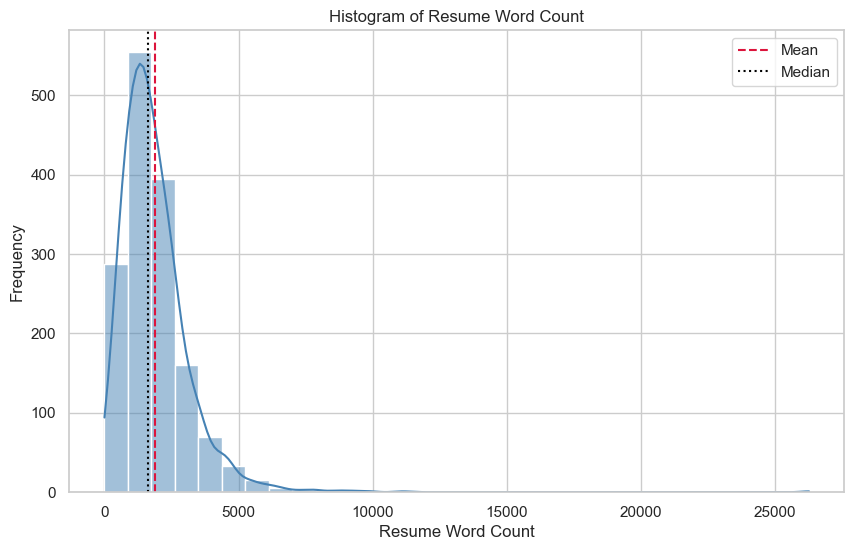

In [69]:
# 1. Histogram: distribution of resume lengths
plt.figure(figsize=(10, 6))
sns.histplot(eda_df['resume_word_count'], bins=30, kde=True, color='steelblue')
plt.axvline(eda_df['resume_word_count'].mean(), color='crimson', linestyle='--', label='Mean')
plt.axvline(eda_df['resume_word_count'].median(), color='black', linestyle=':', label='Median')
plt.title('Histogram of Resume Word Count')
plt.xlabel('Resume Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()


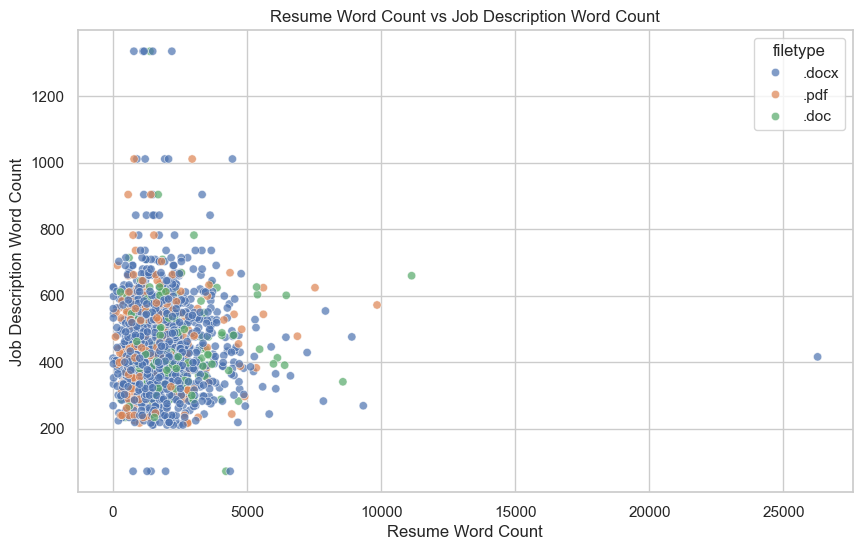

In [70]:
# 2. Scatter plot: relationship between resume length and job description length
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=eda_df,
    x='resume_word_count',
    y='job_word_count',
    hue='filetype',
    alpha=0.7
)
plt.title('Resume Word Count vs Job Description Word Count')
plt.xlabel('Resume Word Count')
plt.ylabel('Job Description Word Count')
plt.show()


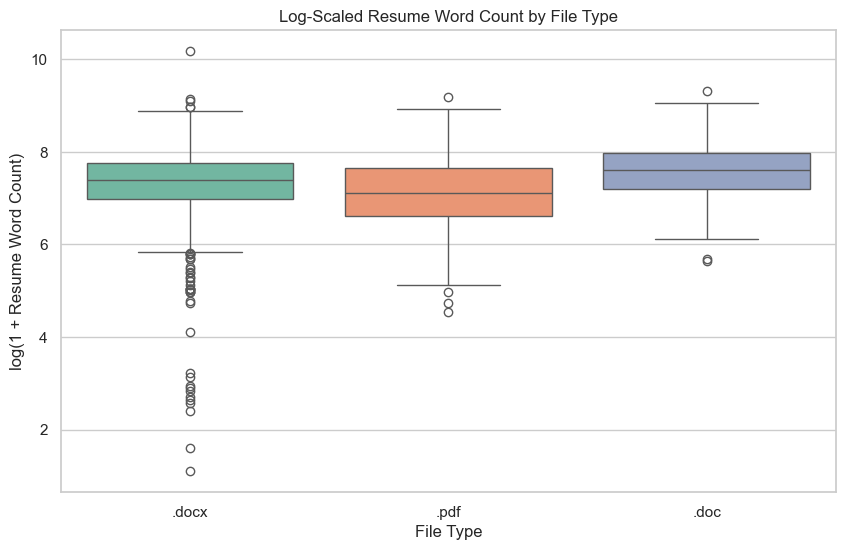

In [71]:
# 3. Log-scaled box plot: compare central tendency by file type without letting very long resumes dominate the scale
eda_df['log_resume_word_count'] = np.log1p(eda_df['resume_word_count'])
plt.figure(figsize=(10, 6))
sns.boxplot(data=eda_df, x='filetype', y='log_resume_word_count', hue='filetype', dodge=False, palette='Set2')
legend = plt.gca().get_legend()
if legend is not None:
    legend.remove()
plt.title('Log-Scaled Resume Word Count by File Type')
plt.xlabel('File Type')
plt.ylabel('log(1 + Resume Word Count)')
plt.show()


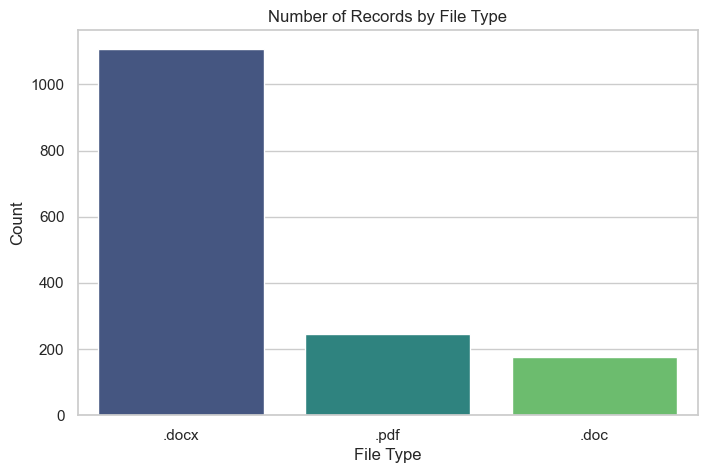

In [72]:
# 4. Bar chart: count of records by file type
plt.figure(figsize=(8, 5))
order = eda_df['filetype'].value_counts().index
sns.countplot(data=eda_df, x='filetype', order=order, hue='filetype', dodge=False, palette='viridis')
legend = plt.gca().get_legend()
if legend is not None:
    legend.remove()
plt.title('Number of Records by File Type')
plt.xlabel('File Type')
plt.ylabel('Count')
plt.show()


## Extra Text-Aware EDA
Because this project uses long text documents, standard tabular EDA is not enough on its own. The extra features below make the analysis more explainable:
- lexical diversity shows how repetitive or varied the language is
- shared token overlap measures rough alignment between each resume and its paired job description
- IQR-based outlier flags isolate unusually long resumes without using arbitrary thresholds


In [73]:
text_feature_cols = [
    'resume_avg_token_length',
    'job_avg_token_length',
    'resume_long_token_ratio',
    'job_long_token_ratio',
    'resume_unique_token_count',
    'job_unique_token_count',
    'resume_lexical_diversity',
    'job_lexical_diversity',
    'shared_token_count',
    'shared_token_ratio',
    'tailored_content_block_count',
    'tailored_experience_bullet_count',
    'tailored_skill_item_count'
]

outlier_summary = pd.DataFrame({
    'metric': ['outlier_count', 'outlier_rate_percent'],
    'value': [
        int(eda_df['resume_length_outlier'].sum()),
        round(eda_df['resume_length_outlier'].mean() * 100, 2)
    ]
})

filetype_medians = eda_df.groupby('filetype')[
    ['resume_word_count', 'job_word_count', 'shared_token_ratio']
].median().round(2)

display(eda_df[text_feature_cols].describe().T)
display(outlier_summary)
display(filetype_medians)
print('Top Resume Bigrams')
display(resume_top_bigrams)
print('Top Job Description Bigrams')
display(job_top_bigrams)


,count,mean,std,min,25%,50%,75%,max
resume_avg_token_length,1530.0,7.292991,3.418480,0.000000,6.890199,7.090977,7.327627,89.033898
job_avg_token_length,1530.0,9.222468,0.438044,7.959064,8.922131,9.211268,9.469230,10.560714
resume_long_token_ratio,1530.0,0.418262,0.063818,0.000000,0.387649,0.415544,0.450000,1.000000
job_long_token_ratio,1530.0,0.553854,0.038951,0.433447,0.526471,0.554830,0.578947,0.655172
resume_unique_token_count,1530.0,601.262745,336.729617,0.000000,410.250000,569.500000,740.750000,7880.000000
job_unique_token_count,1530.0,262.781046,65.354152,54.000000,224.000000,260.000000,310.000000,463.000000
resume_lexical_diversity,1530.0,0.490404,0.124849,0.000000,0.407256,0.474146,0.556148,1.000000
job_lexical_diversity,1530.0,0.789825,0.055987,0.513514,0.765661,0.795455,0.827692,0.899123
shared_token_count,1530.0,41.624183,20.040197,0.000000,27.000000,40.000000,53.000000,121.000000
shared_token_ratio,1530.0,0.156794,0.060439,0.000000,0.116469,0.155280,0.194227,0.412879


,metric,value
0,outlier_count,58.00
1,outlier_rate_percent,3.79


,resume_word_count,job_word_count,shared_token_ratio
filetype,,,
.doc,2008.0,416.0,0.16
.docx,1631.0,425.0,0.16
.pdf,1231.0,430.0,0.14


Top Resume Bigrams


,ngram,count
0,web services,2686
1,sql server,2289
2,test cases,2279
3,business requirements,1846
4,design development,1348
5,business process,1345
6,life cycle,1294
7,software development,1210
8,years experience,1050
9,project management,1037


Top Job Description Bigrams


,ngram,count
0,jobs united,1530
1,data provided,1524
2,provided crunchbaseboost,1524
3,crunchbaseboost interview,1524
4,interview chancesimprove,1524
5,chancesimprove resume,1524
6,resume match,1524
7,match scorefree,1524
8,applicantsmust-have skills,1524
9,my resumeget,1524


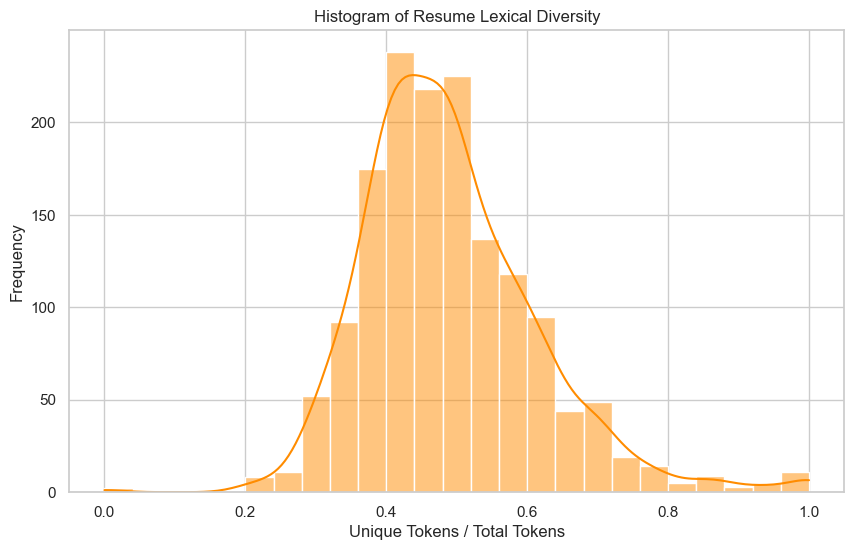

In [74]:
# 5. Histogram: lexical diversity of resume text
plt.figure(figsize=(10, 6))
sns.histplot(eda_df['resume_lexical_diversity'], bins=25, kde=True, color='darkorange')
plt.title('Histogram of Resume Lexical Diversity')
plt.xlabel('Unique Tokens / Total Tokens')
plt.ylabel('Frequency')
plt.show()


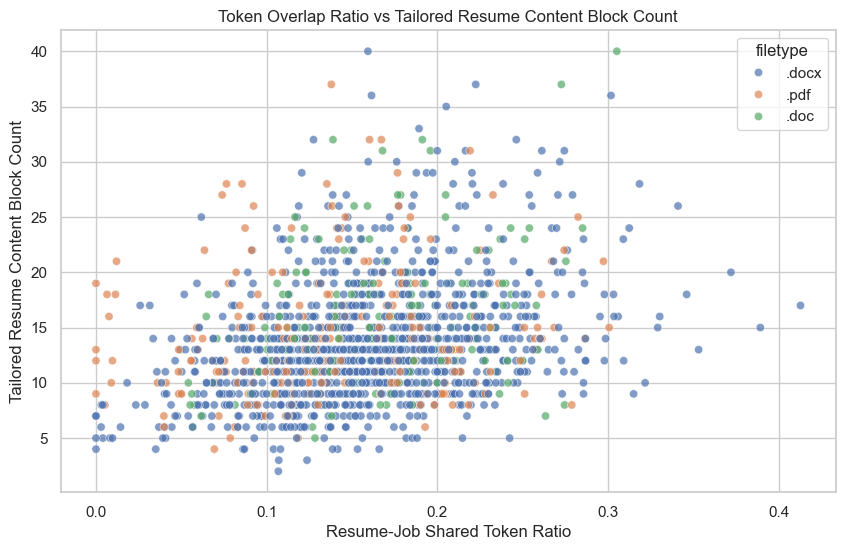

In [75]:
# 6. Scatter plot: shared token overlap vs tailored content density
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=eda_df,
    x='shared_token_ratio',
    y='tailored_content_block_count',
    hue='filetype',
    alpha=0.7
)
plt.title('Token Overlap Ratio vs Tailored Resume Content Block Count')
plt.xlabel('Resume-Job Shared Token Ratio')
plt.ylabel('Tailored Resume Content Block Count')
plt.show()


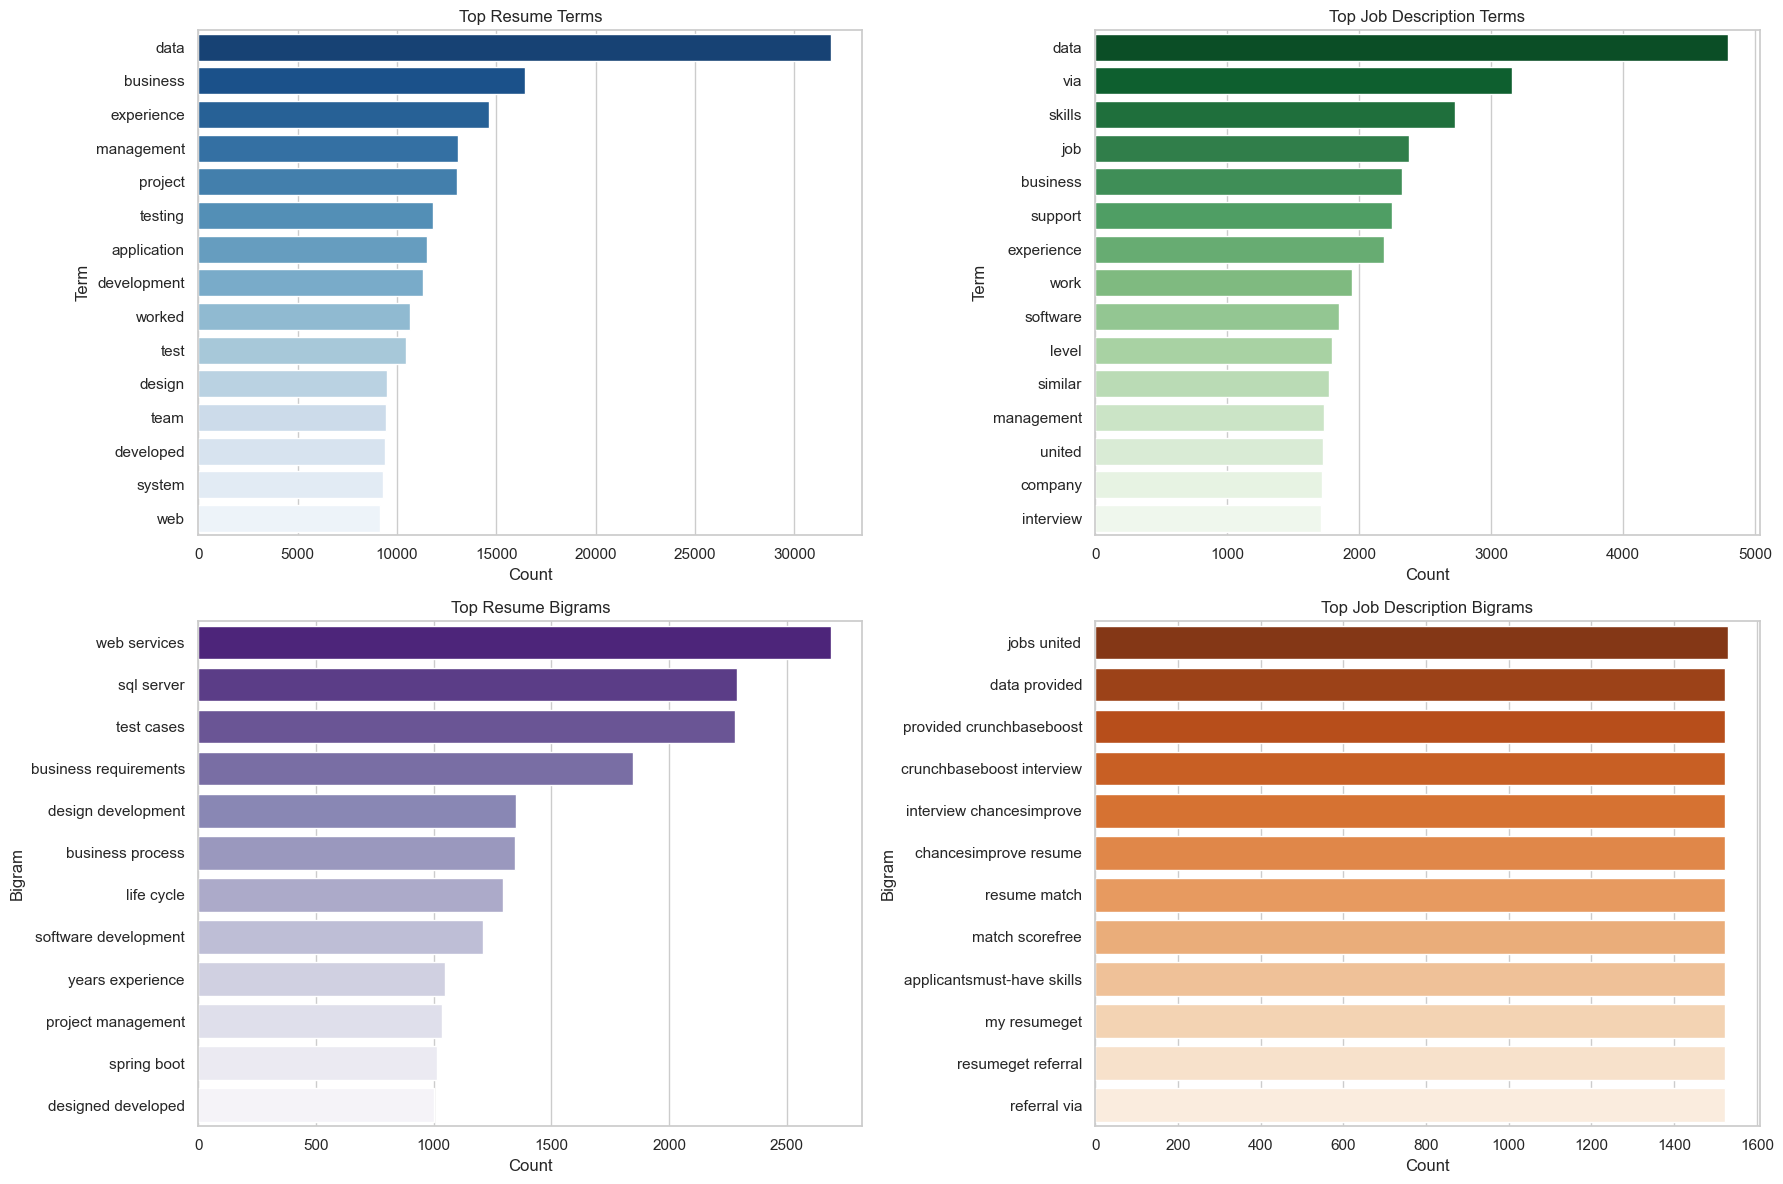

In [76]:
# 7. Bar charts: common tokens and bigrams in resumes and job descriptions
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(data=resume_top_terms, x='count', y='term', hue='term', dodge=False, palette='Blues_r', ax=axes[0, 0])
if axes[0, 0].legend_ is not None:
    axes[0, 0].legend_.remove()
axes[0, 0].set_title('Top Resume Terms')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('Term')

sns.barplot(data=job_top_terms, x='count', y='term', hue='term', dodge=False, palette='Greens_r', ax=axes[0, 1])
if axes[0, 1].legend_ is not None:
    axes[0, 1].legend_.remove()
axes[0, 1].set_title('Top Job Description Terms')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('Term')

sns.barplot(data=resume_top_bigrams, x='count', y='ngram', hue='ngram', dodge=False, palette='Purples_r', ax=axes[1, 0])
if axes[1, 0].legend_ is not None:
    axes[1, 0].legend_.remove()
axes[1, 0].set_title('Top Resume Bigrams')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('Bigram')

sns.barplot(data=job_top_bigrams, x='count', y='ngram', hue='ngram', dodge=False, palette='Oranges_r', ax=axes[1, 1])
if axes[1, 1].legend_ is not None:
    axes[1, 1].legend_.remove()
axes[1, 1].set_title('Top Job Description Bigrams')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Bigram')

plt.tight_layout()
plt.show()


## Descriptive Statistics
This section first computes the required means, medians, and correlations for the main EDA features, then shows the broader numeric summary for the full engineered feature set.


In [77]:
required_stats_cols = [
    'resume_word_count',
    'job_word_count',
    'resume_unique_token_count',
    'job_unique_token_count',
    'resume_lexical_diversity',
    'job_lexical_diversity',
    'shared_token_ratio',
    'tailored_content_block_count',
    'tailored_experience_bullet_count',
    'tailored_skill_item_count'
]

required_means = eda_df[required_stats_cols].mean().rename('mean')
required_medians = eda_df[required_stats_cols].median().rename('median')
required_summary_table = pd.concat([required_means, required_medians], axis=1).round(4)
required_correlation_matrix = eda_df[required_stats_cols].corr(numeric_only=True).round(4)

numeric_cols = [
    'resume_char_count',
    'resume_word_count',
    'job_char_count',
    'job_word_count',
    'resume_avg_token_length',
    'job_avg_token_length',
    'resume_long_token_ratio',
    'job_long_token_ratio',
    'filename_length',
    'resume_to_job_word_ratio',
    'resume_unique_token_count',
    'job_unique_token_count',
    'resume_lexical_diversity',
    'job_lexical_diversity',
    'shared_token_count',
    'shared_token_ratio',
    'tailored_content_block_count',
    'tailored_experience_bullet_count',
    'tailored_skill_item_count'
]

means = eda_df[numeric_cols].mean().rename('mean')
medians = eda_df[numeric_cols].median().rename('median')
summary_table = pd.concat([means, medians], axis=1).sort_index().round(4)
correlation_matrix = eda_df[numeric_cols].corr(numeric_only=True).round(4)
filetype_numeric_summary = eda_df.groupby('filetype')[numeric_cols].median().round(2)

display(required_summary_table)
display(required_correlation_matrix)
display(summary_table)
display(eda_df[numeric_cols].describe().T)
display(filetype_numeric_summary)
display(correlation_matrix)


,mean,median
resume_word_count,1876.6464,1628.0000
job_word_count,446.9353,426.0000
resume_unique_token_count,601.2627,569.5000
job_unique_token_count,262.7810,260.0000
resume_lexical_diversity,0.4904,0.4741
job_lexical_diversity,0.7898,0.7955
shared_token_ratio,0.1568,0.1553
tailored_content_block_count,13.8046,13.0000
tailored_experience_bullet_count,25.4928,19.0000
tailored_skill_item_count,29.9516,25.0000


,resume_word_count,job_word_count,resume_unique_token_count,job_unique_token_count,resume_lexical_diversity,job_lexical_diversity,shared_token_ratio,tailored_content_block_count,tailored_experience_bullet_count,tailored_skill_item_count
resume_word_count,1.0000,-0.0091,0.9087,-0.0019,-0.6351,0.0156,0.5832,0.1985,0.2933,0.2067
job_word_count,-0.0091,1.0000,-0.0204,0.9390,0.0067,-0.6200,0.0910,0.0535,0.0549,0.1215
resume_unique_token_count,0.9087,-0.0204,1.0000,-0.0141,-0.5540,0.0217,0.6650,0.2150,0.2514,0.2144
job_unique_token_count,-0.0019,0.9390,-0.0141,1.0000,0.0053,-0.3970,0.1068,0.0613,0.0714,0.1583
resume_lexical_diversity,-0.6351,0.0067,-0.5540,0.0053,1.0000,0.0016,-0.5585,-0.1787,-0.3387,-0.1898
job_lexical_diversity,0.0156,-0.6200,0.0217,-0.3970,0.0016,1.0000,-0.0697,-0.0297,-0.0215,-0.0354
shared_token_ratio,0.5832,0.0910,0.6650,0.1068,-0.5585,-0.0697,1.0000,0.3003,0.2956,0.3635
tailored_content_block_count,0.1985,0.0535,0.2150,0.0613,-0.1787,-0.0297,0.3003,1.0000,0.4556,0.5074
tailored_experience_bullet_count,0.2933,0.0549,0.2514,0.0714,-0.3387,-0.0215,0.2956,0.4556,1.0000,0.4953
tailored_skill_item_count,0.2067,0.1215,0.2144,0.1583,-0.1898,-0.0354,0.3635,0.5074,0.4953,1.0000


,mean,median
filename_length,23.0778,22.0000
job_avg_token_length,9.2225,9.2113
job_char_count,3923.3601,3723.5000
job_lexical_diversity,0.7898,0.7955
job_long_token_ratio,0.5539,0.5548
job_unique_token_count,262.7810,260.0000
job_word_count,446.9353,426.0000
resume_avg_token_length,7.2930,7.0910
resume_char_count,13075.8778,11564.5000
resume_lexical_diversity,0.4904,0.4741


,count,mean,std,min,25%,50%,75%,max
resume_char_count,1530.0,13075.877778,9512.580372,23.000000,7482.000000,11564.500000,16623.250000,201591.000000
resume_word_count,1530.0,1876.646405,1373.198450,2.000000,1039.500000,1628.000000,2408.250000,26274.000000
job_char_count,1530.0,3923.360131,1126.899783,664.000000,3234.000000,3723.500000,4595.000000,9988.000000
job_word_count,1530.0,446.935294,142.141573,72.000000,356.250000,426.000000,533.000000,1335.000000
resume_avg_token_length,1530.0,7.292991,3.418480,0.000000,6.890199,7.090977,7.327627,89.033898
job_avg_token_length,1530.0,9.222468,0.438044,7.959064,8.922131,9.211268,9.469230,10.560714
resume_long_token_ratio,1530.0,0.418262,0.063818,0.000000,0.387649,0.415544,0.450000,1.000000
job_long_token_ratio,1530.0,0.553854,0.038951,0.433447,0.526471,0.554830,0.578947,0.655172
filename_length,1530.0,23.077778,7.893658,5.000000,18.000000,22.000000,26.000000,91.000000
resume_to_job_word_ratio,1530.0,4.665731,4.230759,0.004854,2.235328,3.757984,5.909669,63.158654


,resume_char_count,resume_word_count,job_char_count,job_word_count,resume_avg_token_length,job_avg_token_length,resume_long_token_ratio,job_long_token_ratio,filename_length,resume_to_job_word_ratio,resume_unique_token_count,job_unique_token_count,resume_lexical_diversity,job_lexical_diversity,shared_token_count,shared_token_ratio,tailored_content_block_count,tailored_experience_bullet_count,tailored_skill_item_count
filetype,,,,,,,,,,,,,,,,,,,
.doc,14212.0,2008.0,3650.0,416.0,7.02,9.21,0.41,0.55,22.0,4.71,647.0,252.0,0.43,0.80,44.0,0.16,15.0,19.0,25.0
.docx,11619.0,1631.0,3714.0,425.0,7.11,9.21,0.42,0.55,22.0,3.83,568.5,258.0,0.47,0.80,40.0,0.16,13.0,20.0,25.0
.pdf,8728.0,1231.0,3787.0,430.0,7.04,9.16,0.41,0.56,21.0,2.97,477.0,262.0,0.53,0.79,36.0,0.14,13.0,17.0,25.0


,resume_char_count,resume_word_count,job_char_count,job_word_count,resume_avg_token_length,job_avg_token_length,resume_long_token_ratio,job_long_token_ratio,filename_length,resume_to_job_word_ratio,resume_unique_token_count,job_unique_token_count,resume_lexical_diversity,job_lexical_diversity,shared_token_count,shared_token_ratio,tailored_content_block_count,tailored_experience_bullet_count,tailored_skill_item_count
resume_char_count,1.0000,0.9749,-0.0179,-0.0190,-0.0089,0.0061,-0.0883,-0.0140,0.1298,0.7906,0.9508,-0.0119,-0.6287,0.0219,0.4896,0.6172,0.2038,0.2926,0.2119
resume_word_count,0.9749,1.0000,-0.0078,-0.0091,-0.0359,0.0018,-0.1877,-0.0096,0.1241,0.8032,0.9087,-0.0019,-0.6351,0.0156,0.4617,0.5832,0.1985,0.2933,0.2067
job_char_count,-0.0179,-0.0078,1.0000,0.9884,-0.0087,-0.3946,-0.0294,0.0355,-0.0191,-0.3541,-0.0211,0.9527,-0.0002,-0.6137,0.5615,0.1076,0.0586,0.0615,0.1433
job_word_count,-0.0190,-0.0091,0.9884,1.0000,-0.0105,-0.4846,-0.0295,-0.0430,-0.0246,-0.3472,-0.0204,0.9390,0.0067,-0.6200,0.5418,0.0910,0.0535,0.0549,0.1215
resume_avg_token_length,-0.0089,-0.0359,-0.0087,-0.0105,1.0000,0.0225,0.4735,0.0260,0.0413,-0.0414,-0.0831,-0.0087,0.2508,0.0078,-0.1020,-0.1279,0.0384,0.0328,0.0269
job_avg_token_length,0.0061,0.0018,-0.3946,-0.4846,0.0225,1.0000,0.0066,0.6720,0.0363,0.1648,-0.0027,-0.4782,-0.0376,0.2383,-0.2261,0.0121,-0.0316,-0.0465,-0.0288
resume_long_token_ratio,-0.0883,-0.1877,-0.0294,-0.0295,0.4735,0.0066,1.0000,-0.0046,0.0399,-0.1543,-0.0892,-0.0274,0.2465,0.0119,0.0327,0.0359,0.0133,0.0094,-0.0103
job_long_token_ratio,-0.0140,-0.0096,0.0355,-0.0430,0.0260,0.6720,-0.0046,1.0000,0.0215,0.0485,-0.0279,-0.0764,-0.0309,-0.1352,0.0151,0.0635,0.0160,0.0121,0.0771
filename_length,0.1298,0.1241,-0.0191,-0.0246,0.0413,0.0363,0.0399,0.0215,1.0000,0.1265,0.1160,-0.0141,-0.0301,0.0412,0.0258,0.0448,0.0382,0.0318,0.0261
resume_to_job_word_ratio,0.7906,0.8032,-0.3541,-0.3472,-0.0414,0.1648,-0.1543,0.0485,0.1265,1.0000,0.7354,-0.3682,-0.5240,0.1952,0.1300,0.4252,0.1410,0.2109,0.1132


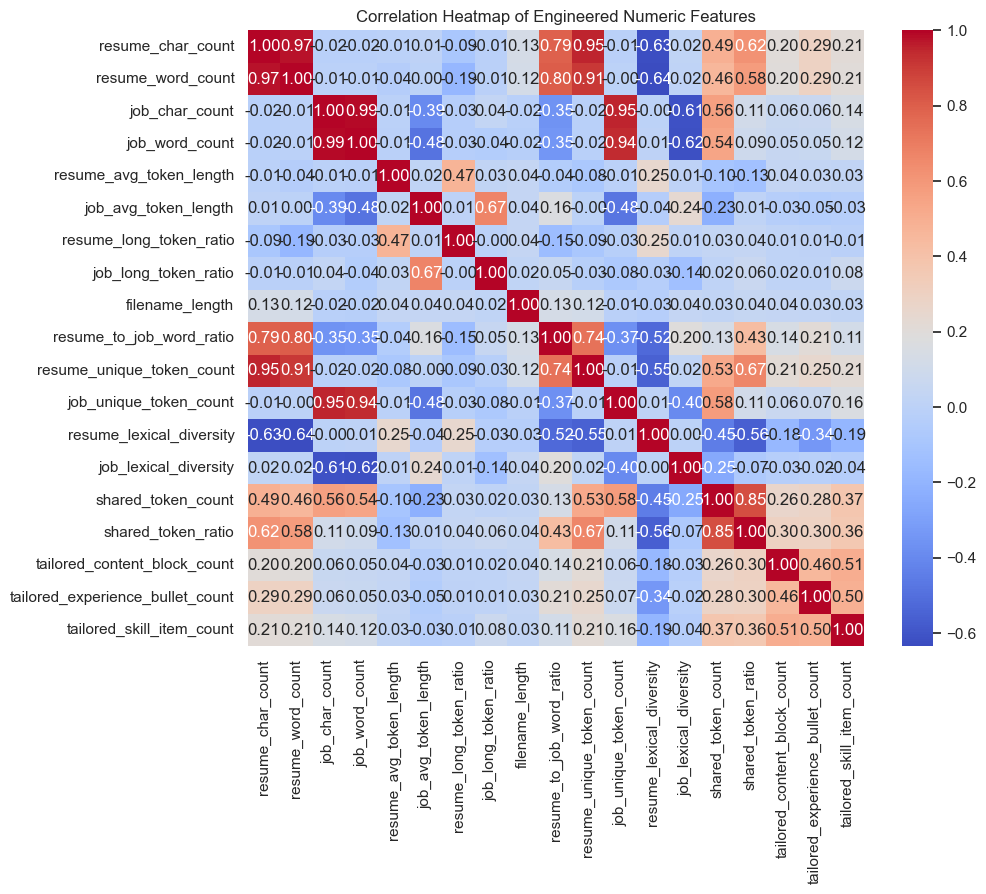

In [78]:
# Correlation heatmap for easier interpretation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Engineered Numeric Features')
plt.show()


## Key Findings You Can Use in the Submission
These findings were calculated directly from the current repository dataset and are reasonable to defend in class:

1. The final EDA dataset contains **1,530 rows** with **0 duplicate rows** at the `(filename, filetype, resume_text, job_description, id)` level.
2. File types are imbalanced but explainable: **72.4% `.docx` (1,108 rows)**, **16.1% `.pdf` (247 rows)**, and **11.4% `.doc` (175 rows)**.
3. Resumes are much longer than job descriptions on average: the mean resume length is **1,876.65 words** and the median is **1,628 words**, while the mean job-description length is **446.94 words** and the median is **426 words**.
4. Resume length outliers are limited, not dominant: only **58 rows (3.79%)** sit above the IQR upper fence of **4,461.38 words**.
5. Resume length and job-description length are essentially unrelated in this dataset (**correlation = -0.0091**), which suggests the pairing process does not simply match long resumes with long job posts.
6. Resume length is strongly associated with resume vocabulary breadth: `resume_word_count` and `resume_unique_token_count` have a strong positive correlation of **0.9087**.
7. Lexical overlap between resumes and job descriptions is moderate but not extreme: the mean shared-token ratio is **0.1568** and the median is **0.1553**.
8. A better output-richness measure is tailored content density, not top-level schema count: the mean `tailored_content_block_count` is **13.80** (median **13**), the mean `tailored_experience_bullet_count` is **25.49**, and the mean `tailored_skill_item_count` is **29.95**.
9. By median resume length, `.doc` files are longest (**2,008 words**), followed by `.docx` (**1,631 words**) and `.pdf` (**1,231 words**).
10. Basic NLP token analysis shows that job descriptions use longer tokens on average than resumes: mean `job_avg_token_length` is **9.22** versus **7.29** for `resume_avg_token_length`. Job descriptions also have a higher long-token ratio (**0.5539** vs **0.4183**), which suggests denser requirement-oriented vocabulary.
11. Common vocabulary across both sources is consistent with the project domain: high-frequency terms include **data**, **business**, **experience**, and **support**, while resume bigrams such as **web services**, **sql server**, and **software development** reinforce the technical focus of the corpus.
12. The top job-description bigrams also reveal repeated scraping boilerplate such as **jobs united**, **data provided**, and **resume match**, which is a useful EDA finding because it shows there is still some repeated template text that could be cleaned further in later preprocessing iterations.

Suggested presentation angle:
- argue that the dataset is large enough for a meaningful Phase 2 EDA
- show that the document lengths are realistic for resumes and job posts
- point out that most records are structured and complete enough to support downstream fine-tuning
- use the correlations to explain which features move together and which do not
